In [167]:
### Knowledge involved
### 1) Implement one-step and multi-step logistic regression updates by hand
### 2) Use numpy for matrix-vector computation
### 3) Basic visualization with matplotlib.pyplot
### Important note: Learn to check the documentation of the package by yourself when learning new functions!
### e.g. for numpy: https://numpy.org/doc/stable/
###      for matplotlib: https://matplotlib.org/stable/api/index.html

In [168]:
### We aim to study a simple logistic regression numerical example.
###       Problem: Breast cancer diagnosis using two normalized features
###       Feature 1: mean radius
###       Feature 2: mean texture
###       Classes: malignant = 1, benign = 0
### We will follow gradient ascent on the log-likelihood step by step.

In [169]:
### Let's first import the packages that we need
import numpy as np
import matplotlib.pyplot as plt

In [170]:
### Now let's construct the input matrix X and output vector y
### The first column of X is all ones, which corresponds to the intercept term
X = np.array([[1.0, 1.0, 0.5],
              [1.0, 0.8, 0.7],
              [1.0, 0.3, 0.2],
              [1.0, 0.1, 0.1],
              [1.0, 0.5, 0.3]])

### Construct the label vector y as a column vector with shape (5,1)
y = np.array([[1.0],
              [1.0],
              [0.0],
              [0.0],
              [0.0]])

### Define the initial weight vector w^(0)
### We use zeros as the initial guess
w = np.array([[0.0],
              [0.0],
              [0.0]])

### Define the learning rate lambda
lam = 0.5

In [171]:
### Define the sigmoid function
### The sigmoid function maps any real number to a value between 0 and 1
### This value can be interpreted as a probability
def sigmoid(z):
    return 1/(1+np.exp(-z))

### Test the sigmoid function at z = 0
### The answer should be 0.5
print('sigmoid(0) =', sigmoid(0))

sigmoid(0) = 0.5


In [172]:
### Step 1: Compute the initial linear predictor eta = Xw
### Since w is currently all zeros, all entries of eta should be zero
eta = X @ w
print('eta^(0) =\n', eta)

### Apply the sigmoid function to eta
### This gives the initial predicted probabilities
sigma = sigmoid(eta)
print('sigma^(0) =\n', sigma)

eta^(0) =
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
sigma^(0) =
 [[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]]


In [173]:
### Step 2: Compute the residual vector r = y - sigma
### Here 'residual' means the difference between the true labels and the predicted probabilities
r = y - sigma
print('r^(0) =\n', r)

### Compute the gradient of the log-likelihood
### For logistic regression, the gradient is X^T (y - sigma)
grad = X.T @ r
print('gradient at iteration 0 =\n', grad)

r^(0) =
 [[ 0.5]
 [ 0.5]
 [-0.5]
 [-0.5]
 [-0.5]]
gradient at iteration 0 =
 [[-0.5 ]
 [ 0.45]
 [ 0.3 ]]


In [174]:
### Step 3: Update the weight vector by gradient ascent
### Since we want to maximize the log-likelihood,
### we move in the direction of the gradient
w = w + lam * grad
print('w^(1) =\n', w)

w^(1) =
 [[-0.25 ]
 [ 0.225]
 [ 0.15 ]]


In [175]:
### Step 4: Compute the new predictions after the first update
eta = X @ w
sigma = sigmoid(eta)

print('eta^(1) =\n', eta)
print('sigma^(1) =\n', sigma)

### Compute the log-likelihood value
loglik = np.sum(y*np.log(sigma) + (1-y)*np.log(1-sigma))
print('log-likelihood after 1 update =', loglik)

eta^(1) =
 [[ 0.05  ]
 [ 0.035 ]
 [-0.1525]
 [-0.2125]
 [-0.0925]]
sigma^(1) =
 [[0.5124974 ]
 [0.50874911]
 [0.46194872]
 [0.44707401]
 [0.47689147]]
log-likelihood after 1 update = -3.204558799140306


In [176]:
### Now let's continue the iterative procedure with a 'for' loop
### This is similar in spirit to the loop structure in your WLS notebook
### We will store the weight vector and log-likelihood at each iteration
w = np.array([[0.0],
              [0.0],
              [0.0]])

num_loop = 100

### Create empty Python lists to store intermediate results
w_history = []
loglik_history = []

for i in range(num_loop):

    ### Compute the linear predictor eta = Xw
    eta = X @ w

    ### Convert eta to probabilities through the sigmoid function
    sigma = sigmoid(eta)

    ### Compute the residual vector y - sigma
    r = y - sigma

    ### Compute the gradient of the log-likelihood
    grad = X.T @ r

    ### Update the weights by gradient ascent
    w = w + lam * grad

    ### Compute the new log-likelihood after the update
    sigma_new = sigmoid(X @ w)
    loglik = np.sum(y*np.log(sigma_new + 1e-12) + (1-y)*np.log(1-sigma_new + 1e-12))

    ### Save a copy of the current weights and the current log-likelihood
    w_history.append(w.copy())
    loglik_history.append(loglik)

    ### Print all important quantities in each iteration
    print('iteration =', i+1)
    print('gradient =\n', grad)
    print('updated weights =\n', w)
    print('log-likelihood =', loglik)
    print('-------------------------------------------')

iteration = 1
gradient =
 [[-0.5 ]
 [ 0.45]
 [ 0.3 ]]
updated weights =
 [[-0.25 ]
 [ 0.225]
 [ 0.15 ]]
log-likelihood = -3.2045587991308104
-------------------------------------------
iteration = 2
gradient =
 [[-0.40716071]
 [ 0.45876556]
 [ 0.30746234]]
updated weights =
 [[-0.45358035]
 [ 0.45438278]
 [ 0.30373117]]
log-likelihood = -2.976362406450842
-------------------------------------------
iteration = 3
gradient =
 [[-0.37780791]
 [ 0.43278063]
 [ 0.29175554]]
updated weights =
 [[-0.64248431]
 [ 0.6707731 ]
 [ 0.44960894]]
log-likelihood = -2.7750118541582385
-------------------------------------------
iteration = 4
gradient =
 [[-0.35548879]
 [ 0.40595601]
 [ 0.27534392]]
updated weights =
 [[-0.8202287]
 [ 0.8737511]
 [ 0.5872809]]
log-likelihood = -2.596900124793733
-------------------------------------------
iteration = 5
gradient =
 [[-0.3354461 ]
 [ 0.38106987]
 [ 0.2600681 ]]
updated weights =
 [[-0.98795176]
 [ 1.06428604]
 [ 0.71731495]]
log-likelihood = -2.438854387

In [177]:
### Let's check the weights after 5 iterations
### Note that the result should be close to:
### [-0.2337, 0.2255, 0.1507]^T
print(f'final weight after {num_loop} iterations =\n', w)

final weight after 100 iterations =
 [[-6.20347709]
 [ 6.37982195]
 [ 4.82207709]]


In [178]:
### Use the final weight vector to compute the final predicted probabilities
eta_final = X @ w
sigma_final = sigmoid(eta_final)

print('final linear predictor =\n', eta_final)
print('final probabilities =\n', sigma_final)

### Convert probabilities to class predictions with threshold 0.5
y_pred = (sigma_final >= 0.5).astype(int)

print('predicted class labels =\n', y_pred)
print('true class labels =\n', y)

### Compute training accuracy
acc = np.mean(y_pred == y)
print('training accuracy =', acc)

final linear predictor =
 [[ 2.5873834 ]
 [ 2.27583443]
 [-3.32511509]
 [-5.08328718]
 [-1.56694299]]
final probabilities =
 [[0.93004517]
 [0.90685578]
 [0.03471957]
 [0.0061613 ]
 [0.17265263]]
predicted class labels =
 [[1]
 [1]
 [0]
 [0]
 [0]]
true class labels =
 [[1.]
 [1.]
 [0.]
 [0.]
 [0.]]
training accuracy = 1.0


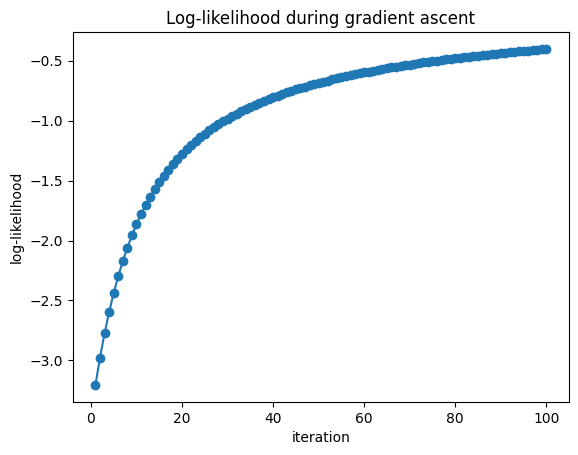

In [179]:
### Visualize how the log-likelihood changes across iterations
### If the algorithm works correctly, the log-likelihood should increase
plt.plot(np.arange(1, num_loop+1), loglik_history, 'o-')
plt.xlabel('iteration')
plt.ylabel('log-likelihood')
plt.title('Log-likelihood during gradient ascent')
plt.show()

In [180]:
### Summary
### 1) We manually implemented logistic regression with gradient ascent
### 2) In each iteration, we computed eta, sigma, residual, gradient, and weight update
### 3) This example is useful for understanding the algorithm before using sklearn
### You can now try:
###    a) changing the learning rate
###    b) increasing the number of iterations
###    c) using a different initial weight vector

In [181]:
w=np.array([0,1])

a=w
b=w.copy()
print(b)

a[0]=2
print(a)
print(w)

[0 1]
[2 1]
[2 1]
